# Week 5 - Function 3 ((19DP, 3D))

# Setup
Let's load all the imports in the top to avoid repeating and simplify the readability of each solution.

In [1]:

import numpy as np

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel
from sklearn.preprocessing import StandardScaler, MinMaxScaler, QuantileTransformer
from sklearn.svm import SVC, SVR
from scipy.stats.qmc import LatinHypercube

from utils.plotting_utils import (
    plot_bar,
    plot_bar_diff,
    plot_3D_mean_uncertainty_slice,
    plot_svm_analysis_slice,
    plot_acquisition_comparison_slice
)


# Plan
We now have ((19, 3)) — 19 data points, 3 dimensions, from `./data/week_5/function_3/`.

**Architecture**: Dual-GP ensemble (QT + log10) with SVM-constrained UCB.

**Key decisions** (carried forward):
- QuantileTransformer + log10 shift: all-negative outputs, compressed range
- UCB kappa=4.31 (budget-aware: week 4/13)
- SVM C=1 soft margin, median threshold, fail-safe at <5% coverage
- 10K LHS candidates for acquisition

**Changes / fixes this week:**
- **Critical**: SVM threshold fixed from `yi > -50` → `yi > np.median(y_log_pos)`. The old threshold labelled all 17 points as "promising" (y_log_pos ∈ [-1.16, -0.78], all above -50), giving 100% SVM coverage and making the constraint useless. Corrected to match the Fn5/6/7 median pattern.
- kappa updated from 5.0 → 4.31 (budget-aware)

**Steps:** Load data → Preprocessing → GP models → SVM → Acquisition → Report


# 1. Load data

In [2]:

X_train_raw = np.load(r"./data/week_5/function_3/inputs.npy")
y_train_raw = np.load(r"./data/week_5/function_3/outputs.npy")

print(f"Shape: X={X_train_raw.shape}, y={y_train_raw.shape}")
print(f"X range: [{X_train_raw.min():.4f}, {X_train_raw.max():.4f}]")
print(f"y range: [{y_train_raw.min():.2e}, {y_train_raw.max():.2e}]")


Shape: X=(19, 3), y=(19,)
X range: [0.0468, 0.9909]
y range: [-3.99e-01, -3.26e-02]


# 2. Preprocessing

The output data contains a significant negative outlier, similar to other functions. `StandardScaler` is ineffective in this scenario as it collapses the variance of the non-outlier points. We will use `QuantileTransformer` to rank the data and spread it uniformly, and also a `log10` transform for positive-only points to model the magnitude differences.

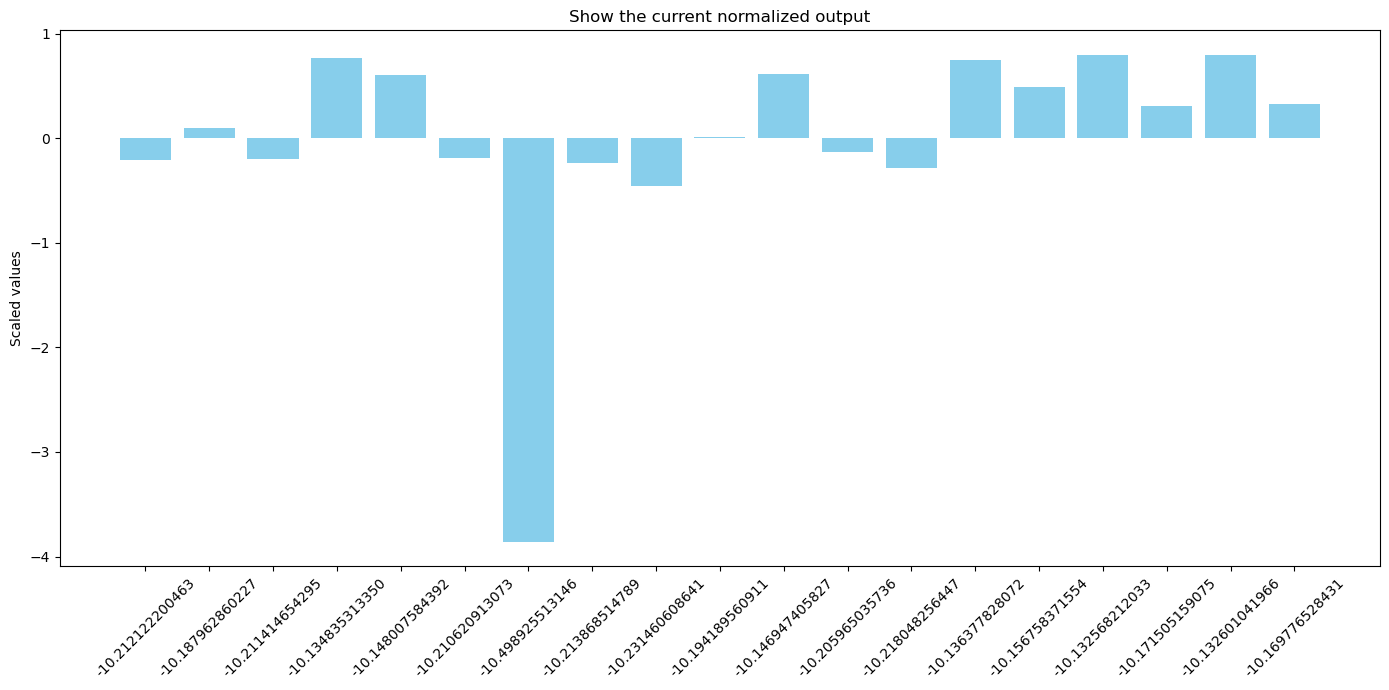

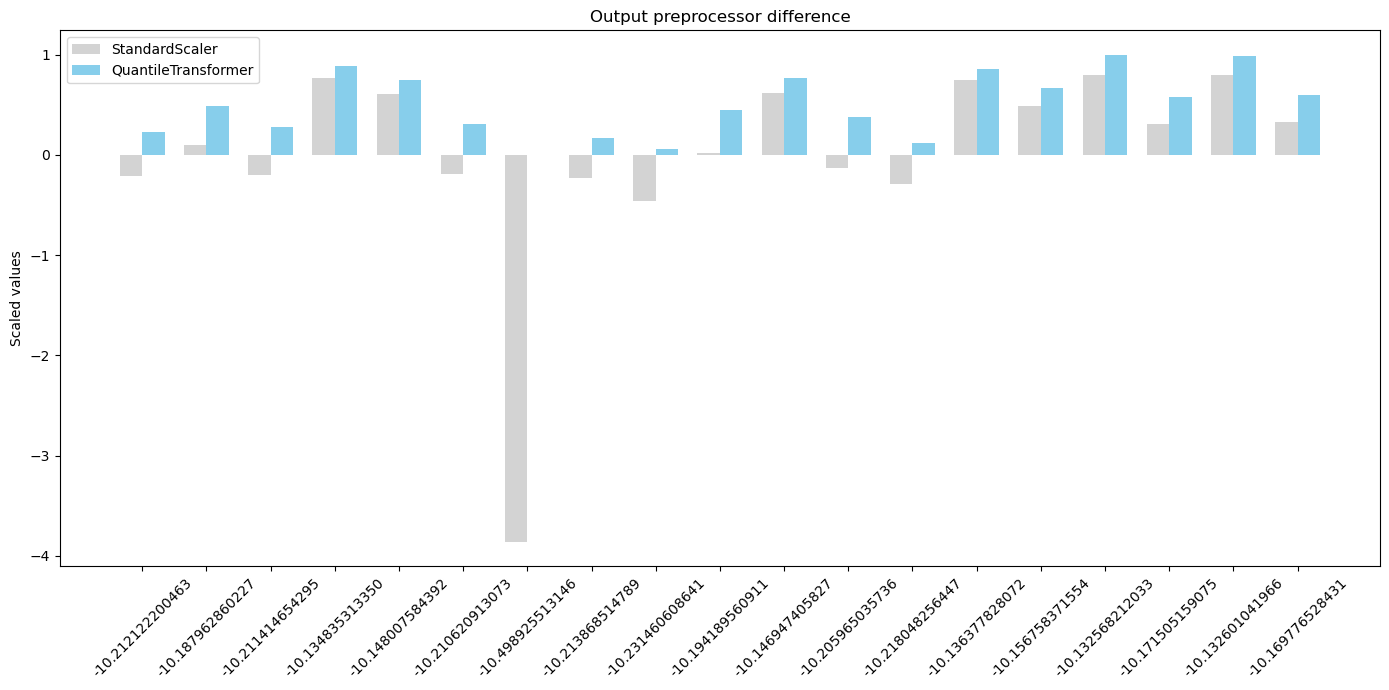

Total points: 19
Range for new normalized output: [0.0, 1.0]
Best point: X=[0.478263 0.705786 0.066089], y=-3.26e-02, QuantileTransformer(y)=1.0

Log shift constant: 1.40
All 19 points included in log space
log10(y_shifted) range: [0.0000, 0.1356]


In [3]:
scaler_X = MinMaxScaler()
X_train = scaler_X.fit_transform(X_train_raw)

scaler_ss = StandardScaler()
y_ss = scaler_ss.fit_transform(y_train_raw.reshape(-1, 1)).ravel()

scaler_qt = QuantileTransformer(n_quantiles=len(y_train_raw)-1, output_distribution='uniform')
y_qt = scaler_qt.fit_transform(y_train_raw.reshape(-1, 1)).ravel()

plot_bar(y_train_raw, y_ss, 'Scaled values', 'Show the current normalized output')

plot_bar_diff(y_train_raw, y_ss, y_qt, 'StandardScaler', 'QuantileTransformer', 'Scaled values', 'Output preprocessor difference')

print(f"Total points: {len(X_train)}")
print(f"Range for new normalized output: [{y_qt.min():.1f}, {y_qt.max():.1f}]")
print(f"Best point: X={X_train_raw[np.argmax(y_train_raw)]}, y={y_train_raw.max():.2e}, QuantileTransformer(y)={y_qt.max():.1f}")

# Log transform: shift by abs(min)+1 guarantees all points positive (min shifted = 1.0).
# Previous shift of 0.2 was insufficient for y_min=-0.399, excluding some training points.
log_shift_constant = abs(y_train_raw.min()) + 1.0
y_train_raw_shifted = y_train_raw + log_shift_constant
X_train_pos = X_train              # all points (no masking needed)
y_log_pos = np.log10(y_train_raw_shifted)

print(f"\nLog shift constant: {log_shift_constant:.2f}")
print(f"All {len(y_train_raw)} points included in log space")
print(f"log10(y_shifted) range: [{y_log_pos.min():.4f}, {y_log_pos.max():.4f}]")

# 3. Build probabilistic Models

We build two GP models with different preprocessing to create a more robust ensemble:
- **gp_qt** (QuantileTransformer, all 18 points): Models the rank-transformed data.
- **gp_log** (log10, positive points): Models the output magnitude in log-space.

GP(QT) kernel: 1.05**2 * Matern(length_scale=[0.929, 0.709, 0.102], nu=2.5)
GP(log) kernel: 1.33**2 * Matern(length_scale=[11.7, 1.4, 0.087], nu=2.5)

GP(QT) length scales: [0.92923717 0.70869192 0.10214503]
  x3: ls=0.1021, importance=79.7%, IMPORTANT
  x2: ls=0.7087, importance=11.5%, IMPORTANT
  x1: ls=0.9292, importance=8.8%, IMPORTANT

GP(log) length scales: [11.65021356  1.39875416  0.0869866 ]
  x3: ls=0.0870, importance=93.5%, IMPORTANT
  x2: ls=1.3988, importance=5.8%, moderate
  x1: ls=11.6502, importance=0.7%, noise


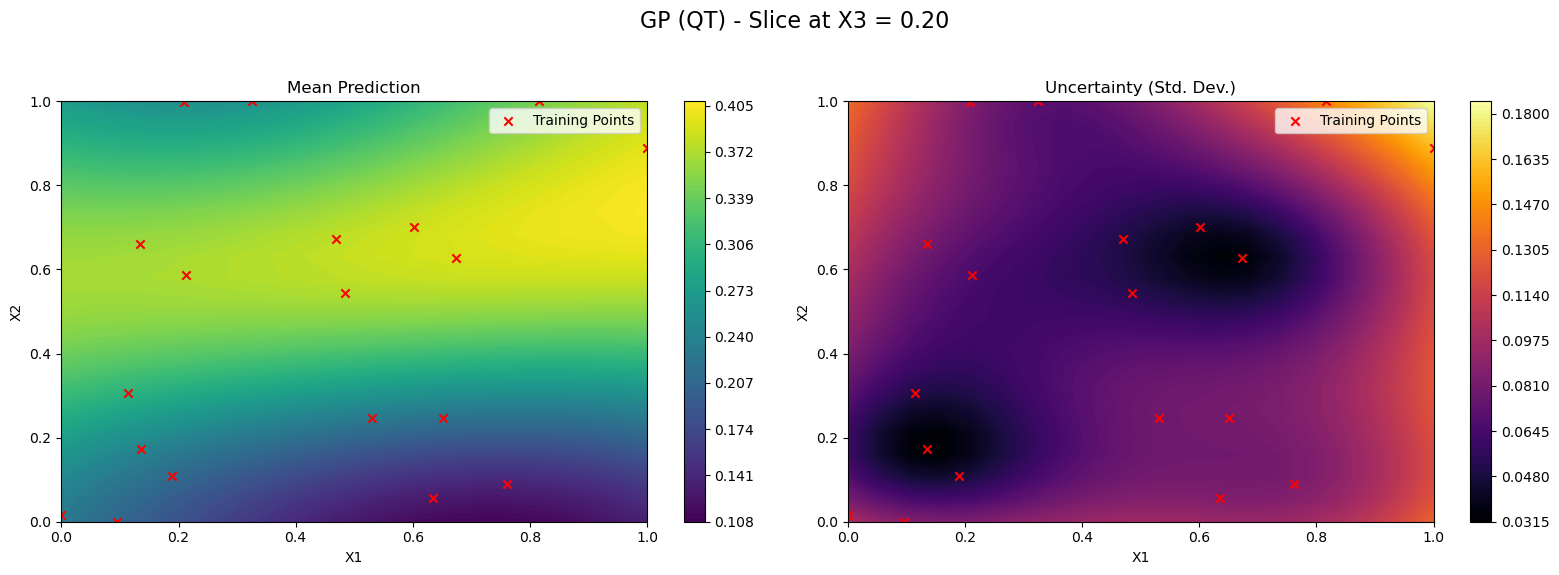

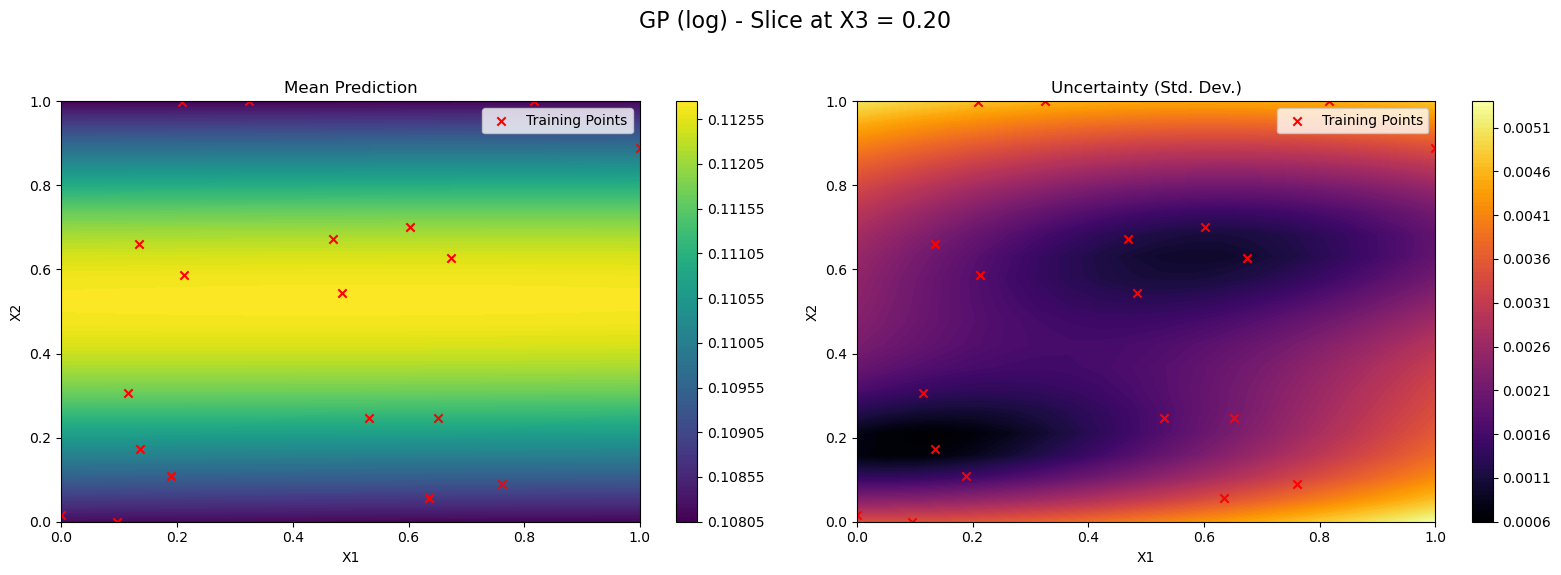

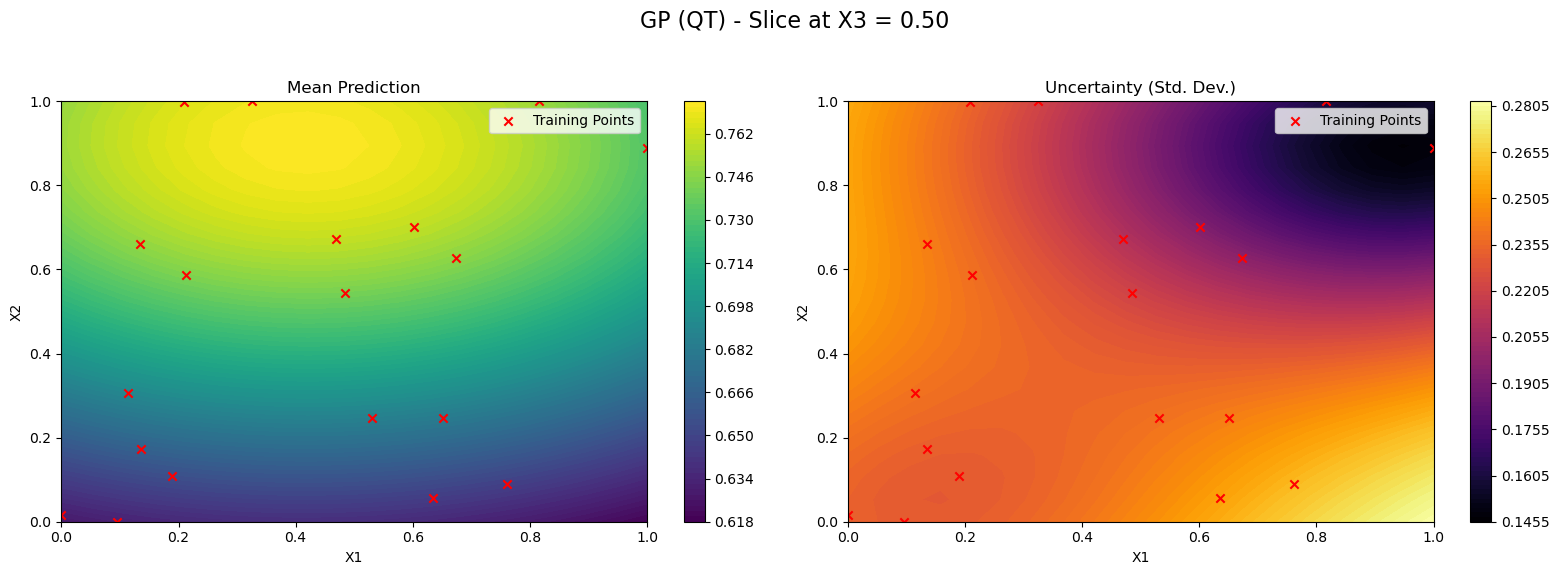

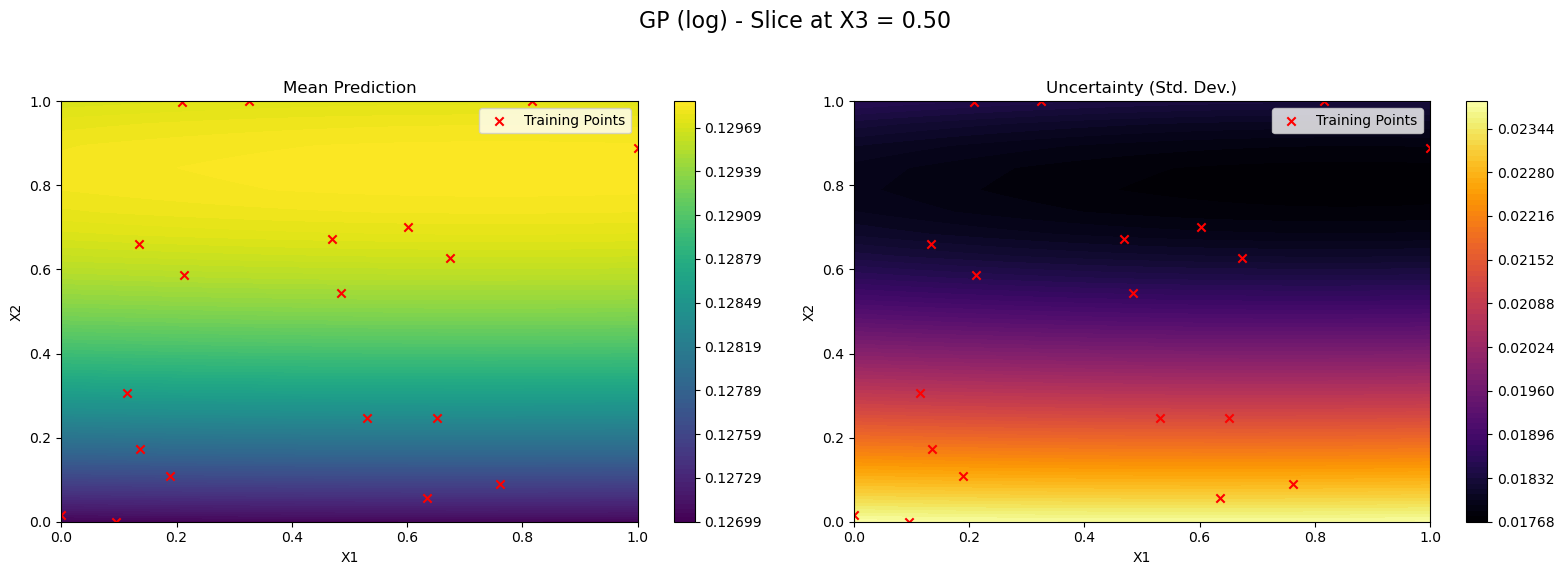

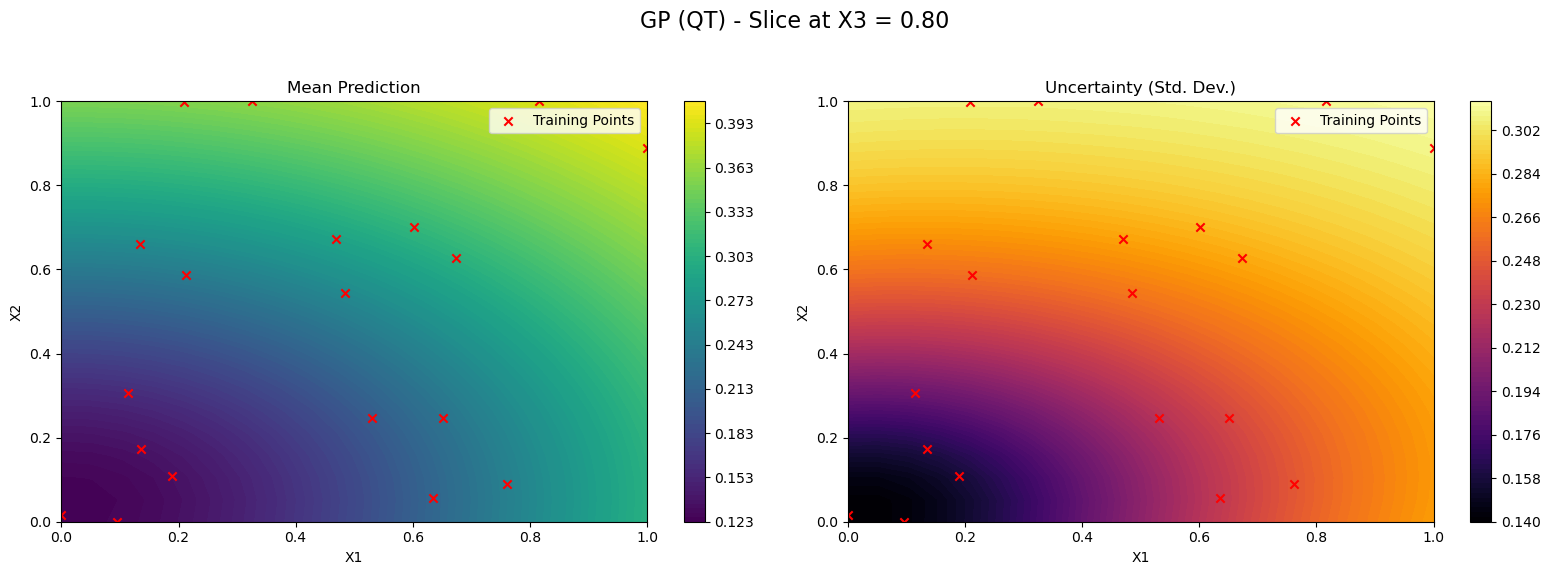

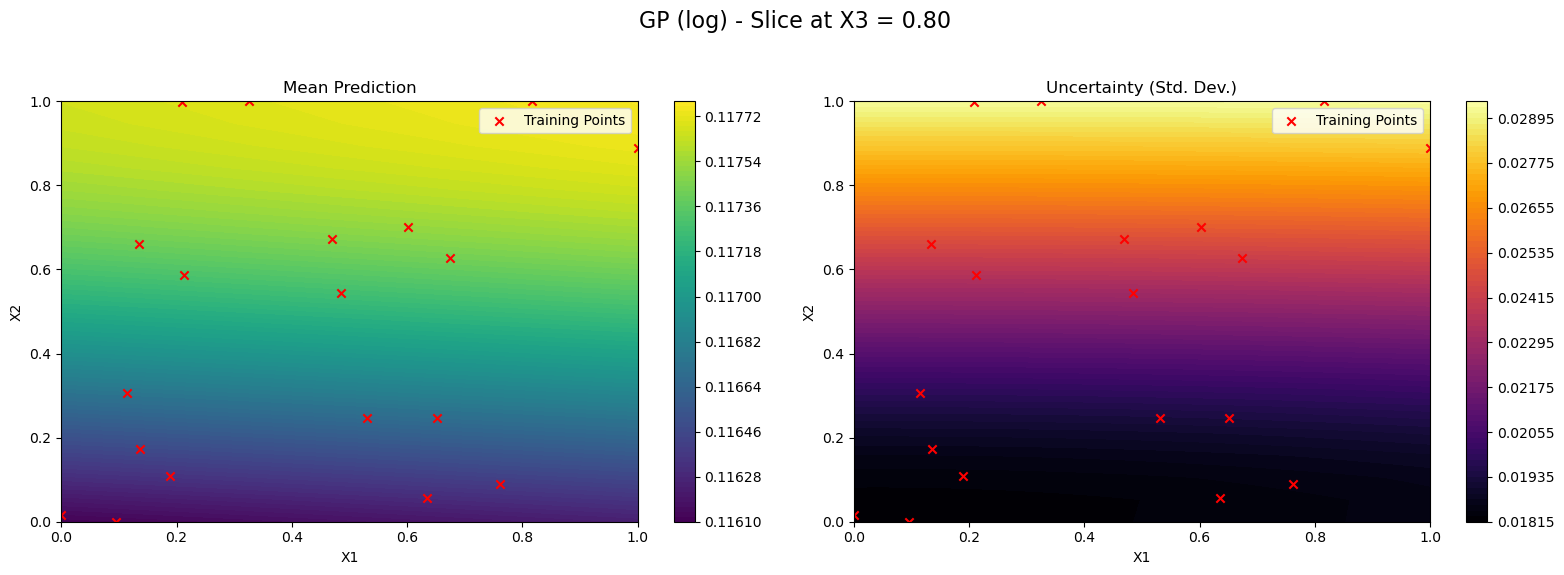

In [4]:
# GP on QuantileTransformer output (all points) — ARD kernel
gp_qt = GaussianProcessRegressor(
    kernel=ConstantKernel(0.25, (1e-3, 10)) * Matern(
        length_scale=[0.5, 0.5, 0.5],
        nu=2.5,
        length_scale_bounds=(0.05, 50.0)
    ),
    alpha=0.01,
    normalize_y=True,
    n_restarts_optimizer=30,
    optimizer='fmin_l_bfgs_b'
)

# GP in log-space on all points (shift guarantees all positive) — ARD kernel
gp_log = GaussianProcessRegressor(
    kernel=ConstantKernel(1.0, (1e-3, 1e3)) * Matern(
        length_scale=[0.3, 0.3, 0.3],
        nu=2.5,
        length_scale_bounds=(1e-3, 50.0)
    ),
    alpha=1e-4,
    normalize_y=True,
    n_restarts_optimizer=50
)

gp_qt.fit(X_train, y_qt)
gp_log.fit(X_train, y_log_pos)

print(f"GP(QT) kernel: {gp_qt.kernel_}")
print(f"GP(log) kernel: {gp_log.kernel_}")

# Feature importance from ARD length scales
for name, gp in [('GP(QT)', gp_qt), ('GP(log)', gp_log)]:
    ls = gp.kernel_.k2.length_scale
    imp = 1.0 / ls
    imp_norm = imp / imp.sum() * 100
    print(f"\n{name} length scales: {ls}")
    sorted_dims = np.argsort(ls)
    for i in sorted_dims:
        role = 'IMPORTANT' if ls[i] < 1.0 else ('moderate' if ls[i] < 5.0 else 'noise')
        print(f"  x{i+1}: ls={ls[i]:.4f}, importance={imp_norm[i]:.1f}%, {role}")

# Create prediction grid (kept for visualization)
n_grid = 20
x1_range = np.linspace(0, 1, n_grid)
x2_range = np.linspace(0, 1, n_grid)
x3_range = np.linspace(0, 1, n_grid)
X1_test, X2_test, X3_test = np.meshgrid(x1_range, x2_range, x3_range)
X_grid = np.c_[X1_test.ravel(), X2_test.ravel(), X3_test.ravel()]

# 2D slice plotting
def plot_gp_slices(x3_slice):
    grid_slice = np.c_[X_grid[:, 0], X_grid[:, 1], np.full_like(X_grid[:, 0], x3_slice)]

    mu_gp_qt, sigma_gp_qt = gp_qt.predict(grid_slice, return_std=True)
    mu_gp_log, sigma_gp_log = gp_log.predict(grid_slice, return_std=True)

    plot_3D_mean_uncertainty_slice(
        X_train, X1_test[:,:,0], X2_test[:,:,0],
        mu_gp_qt.reshape(n_grid, n_grid, n_grid)[:,:, int(x3_slice*(n_grid-1))],
        sigma_gp_qt.reshape(n_grid, n_grid, n_grid)[:,:, int(x3_slice*(n_grid-1))],
        title_prefix="GP (QT)", x3_slice_val=x3_slice
    )
    plot_3D_mean_uncertainty_slice(
        X_train, X1_test[:,:,0], X2_test[:,:,0],
        mu_gp_log.reshape(n_grid, n_grid, n_grid)[:,:, int(x3_slice*(n_grid-1))],
        sigma_gp_log.reshape(n_grid, n_grid, n_grid)[:,:, int(x3_slice*(n_grid-1))],
        title_prefix="GP (log)", x3_slice_val=x3_slice
    )

for x3_val in [0.2, 0.5, 0.8]:
    plot_gp_slices(x3_val)

# 4. SVM Analysis

To handle the penalty zone (negative outputs) and create a more diverse model ensemble, we use three SVMs:
1. **SVM Classifier**: Learns the boundary between 'promising' (positive output) and 'unpromising' (negative output) regions.
2. **SVR Surrogate (log-space)**: An independent surrogate model trained on the log-transformed positive outputs.
3. **SVR Surrogate (QuantileTransformer)**: A second independent surrogate trained on the quantile-transformed outputs.

SVM threshold: 0.1176 | 9 promising / 10 not promising

=== Support Vectors: 17 / 19 training points ===
 Idx         Label        x1        x2        x3         y_raw
   0           not    0.1715    0.3439    0.2487     -0.112122
   1           not    0.2421    0.6441    0.2724     -0.087963
   2           not    0.5349    0.3985    0.1734     -0.111415
   5           not    0.3455    0.9414    0.2694     -0.110621
   6           not    0.1518    0.4400    0.9909     -0.398926
   7           not    0.6455    0.3971    0.9198     -0.113869
   8           not    0.7469    0.2842    0.2263     -0.131461
  11           not    0.6660    0.6720    0.2463     -0.105965
  12           not    0.0468    0.2314    0.7706     -0.118048
   3     promising    0.4926    0.6116    0.3402     -0.034835
  10     promising    0.2205    0.2978    0.3436     -0.046947
  13     promising    0.6001    0.7251    0.0661     -0.036378
  14     promising    0.9660    0.8611    0.5668     -0.056758
  15     prom

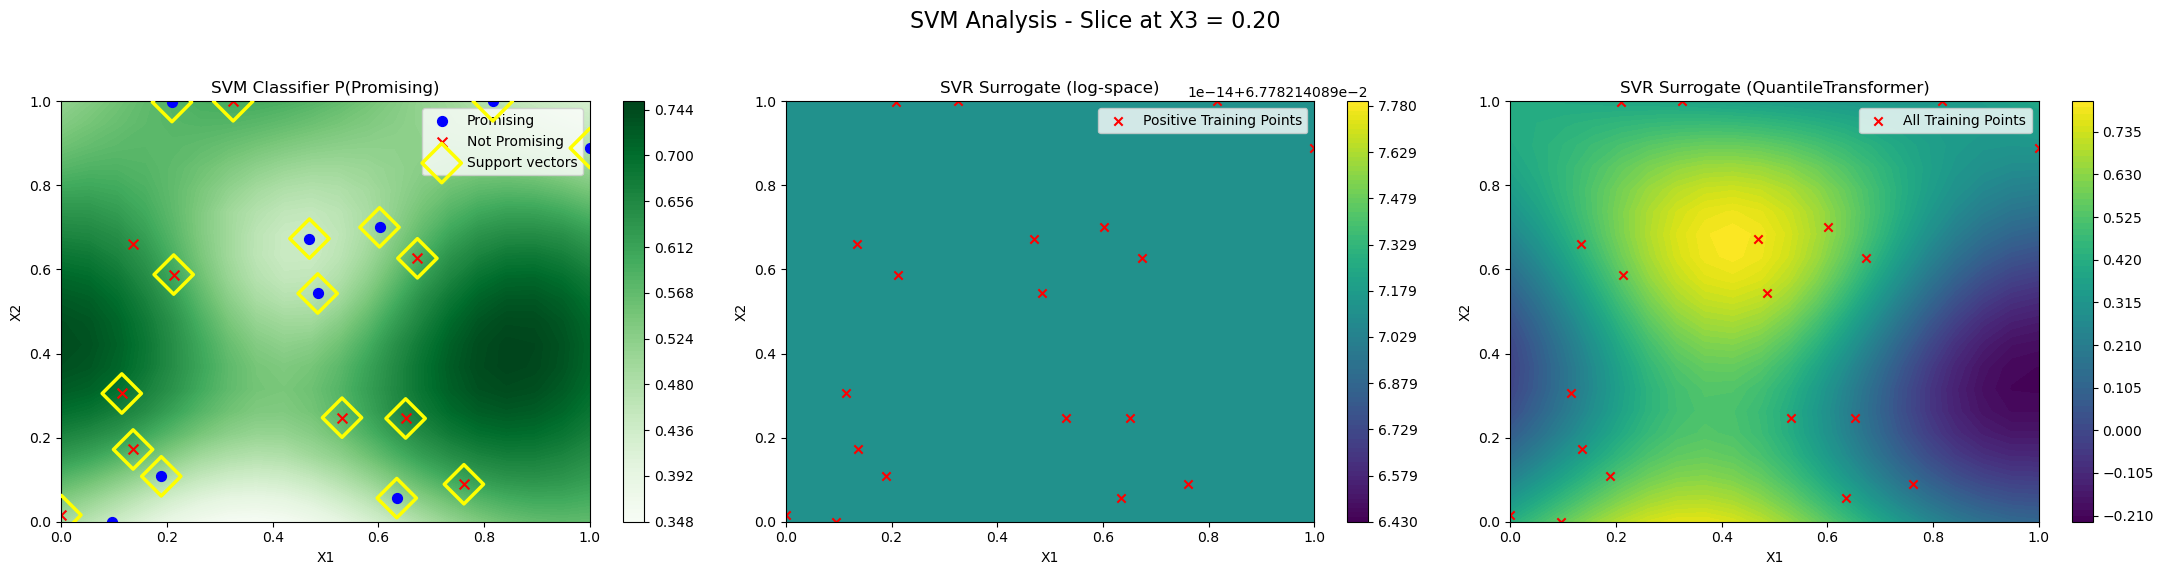

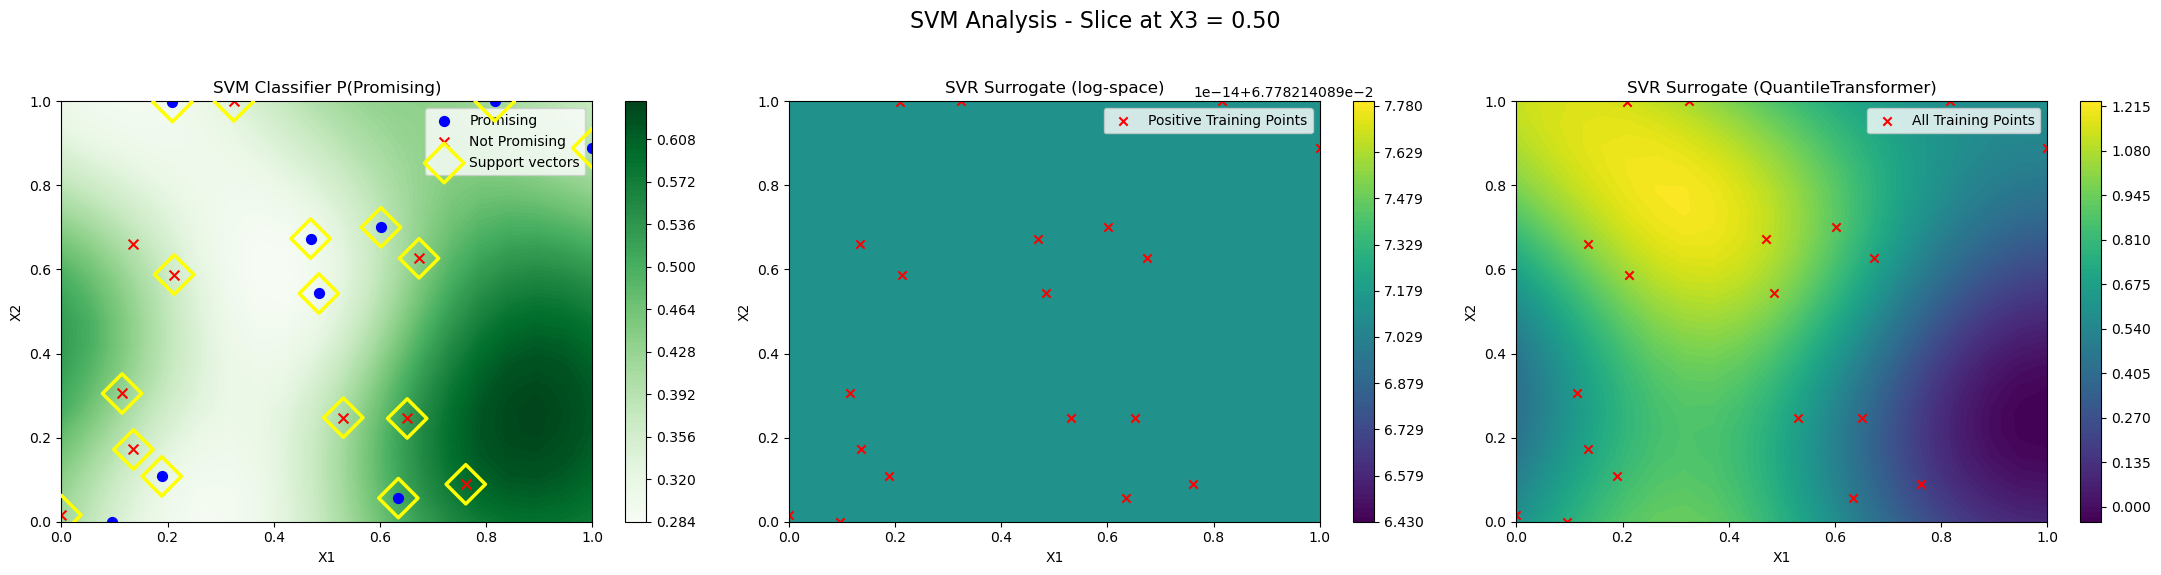

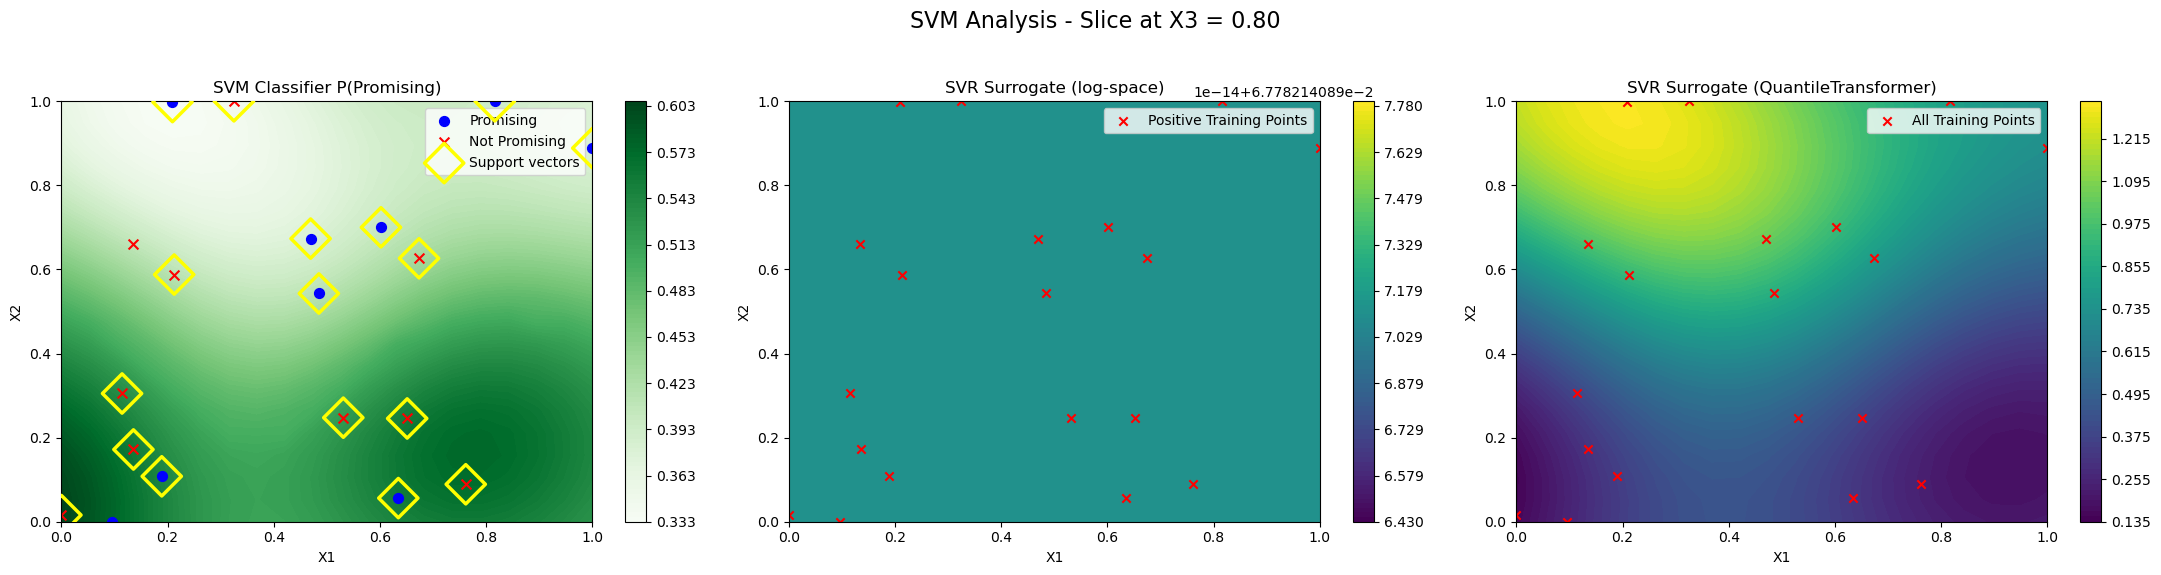

In [5]:
# --- 2a. SVM Classifier: promising vs not-promising regions ---
# Fix B: C reduced from 10 → 1 (softer margin) to prevent decision boundary collapse.
# Fix (Fn3-specific): was `yi > -50` which labelled ALL 17 points as promising.
# Corrected to median threshold; simplified loop since all points are in y_log_pos.
svm_median_threshold = np.median(y_log_pos)
svm_labels = (y_log_pos > svm_median_threshold).astype(int)
n_pos = svm_labels.sum()
n_neg = len(svm_labels) - n_pos

print(f"SVM threshold: {svm_median_threshold:.4f} | {n_pos} promising / {n_neg} not promising")

# gamma=2.0: between 'auto' (too broad → all SVs, flat P) and 'scale' (too local → boundary collapse).
svm_clf = SVC(kernel='rbf', C=10, gamma=6, probability=True)
svm_clf.fit(X_train, svm_labels)

# --- Support Vector Analysis ---
sv_indices = svm_clf.support_
support_vec_mask = np.zeros(len(X_train), dtype=bool)
support_vec_mask[sv_indices] = True

X_sv_orig = scaler_X.inverse_transform(X_train[sv_indices])
y_sv_raw  = y_train_raw[sv_indices]
sv_labels_vals = svm_labels[sv_indices]

print(f"\n=== Support Vectors: {len(sv_indices)} / {len(X_train)} training points ===")
print(f"{'Idx':>4}  {'Label':>12}  {'x1':>8}  {'x2':>8}  {'x3':>8}  {'y_raw':>12}")
for ti, x_o, y_o, lbl in zip(sv_indices, X_sv_orig, y_sv_raw, sv_labels_vals):
    coords = "  ".join(f"{v:>8.4f}" for v in x_o)
    print(f"{ti:>4}  {'promising' if lbl else 'not':>12}  {coords}  {y_o:>12.6f}")

# --- 2b. SVR Surrogate in log-space (all points) ---
svr_log = SVR(kernel='rbf', C=100, gamma=0.1, epsilon=5.0)
svr_log.fit(X_train_pos, y_log_pos)

# --- 2c. SVR Surrogate on QuantileTransformer output (all points) ---
svr_qt = SVR(kernel='rbf', C=100, gamma='scale', epsilon=0.1)
svr_qt.fit(X_train, y_qt)

# --- plotting for SVMs ---
def plot_svm_slices(x3_slice):
    grid_slice = np.c_[X_grid[:, 0], X_grid[:, 1], np.full_like(X_grid[:, 0], x3_slice)]

    svm_proba_slice = svm_clf.predict_proba(grid_slice)[:, 1]
    mu_svr_log_slice = svr_log.predict(grid_slice)
    mu_svr_qt_slice = svr_qt.predict(grid_slice)

    X_train_neg = np.empty((0, X_train.shape[1]))  # no excluded points

    plot_svm_analysis_slice(
        X1_test[:,:,0], X2_test[:,:,0],
        svm_proba_slice.reshape(n_grid, n_grid, n_grid)[:,:, int(x3_slice*(n_grid-1))],
        mu_svr_log_slice.reshape(n_grid, n_grid, n_grid)[:,:, int(x3_slice*(n_grid-1))],
        mu_svr_qt_slice.reshape(n_grid, n_grid, n_grid)[:,:, int(x3_slice*(n_grid-1))],
        X_train, X_train_pos, X_train_neg, svm_labels, x3_slice,
        support_vec_mask=support_vec_mask
    )

for x3_val in [0.2, 0.5, 0.8]:
    plot_svm_slices(x3_val)

# 5. Acquisition Function (SVM-constrained UCB Ensemble)

We combine the GP predictions into a single acquisition function:
- **UCB**: We use Upper Confidence Bound to balance exploration and exploitation.
- **SVM constraint**: The UCB score is multiplied by the SVM's P(promising) to steer the search away from penalty zones.
- **2-GP ensemble**: We average the normalized, constrained UCB scores from both GPs (gp_qt, gp_log) for a robust recommendation.

**Note:** The SVR surrogates are kept for the SVM analysis (Section 4) as independent surface visualizations, but are excluded from the acquisition ensemble. SVRs lack native uncertainty estimates, and with only 17 points in 3D, synthetic uncertainty proxies (e.g. distance-based) consistently over-explore toward boundaries. The two GPs already provide model diversity through different preprocessing (QuantileTransformer vs log-space).

kappa = 4.0769 (week 5/13)


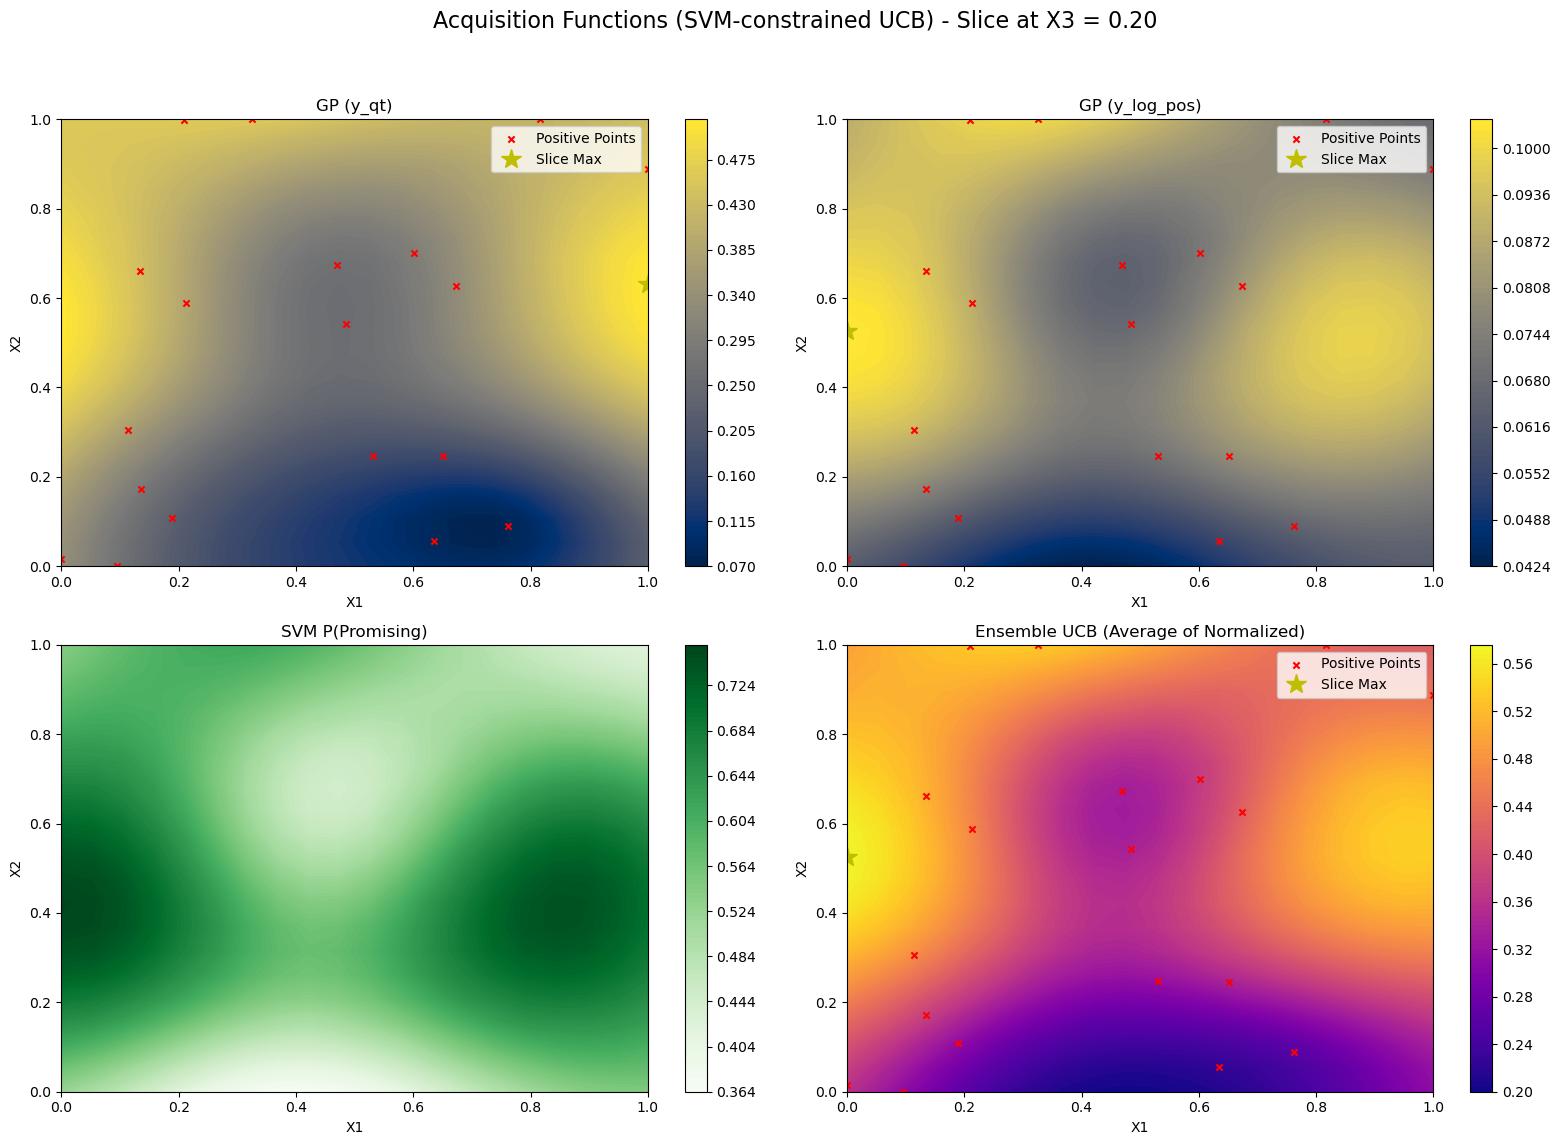

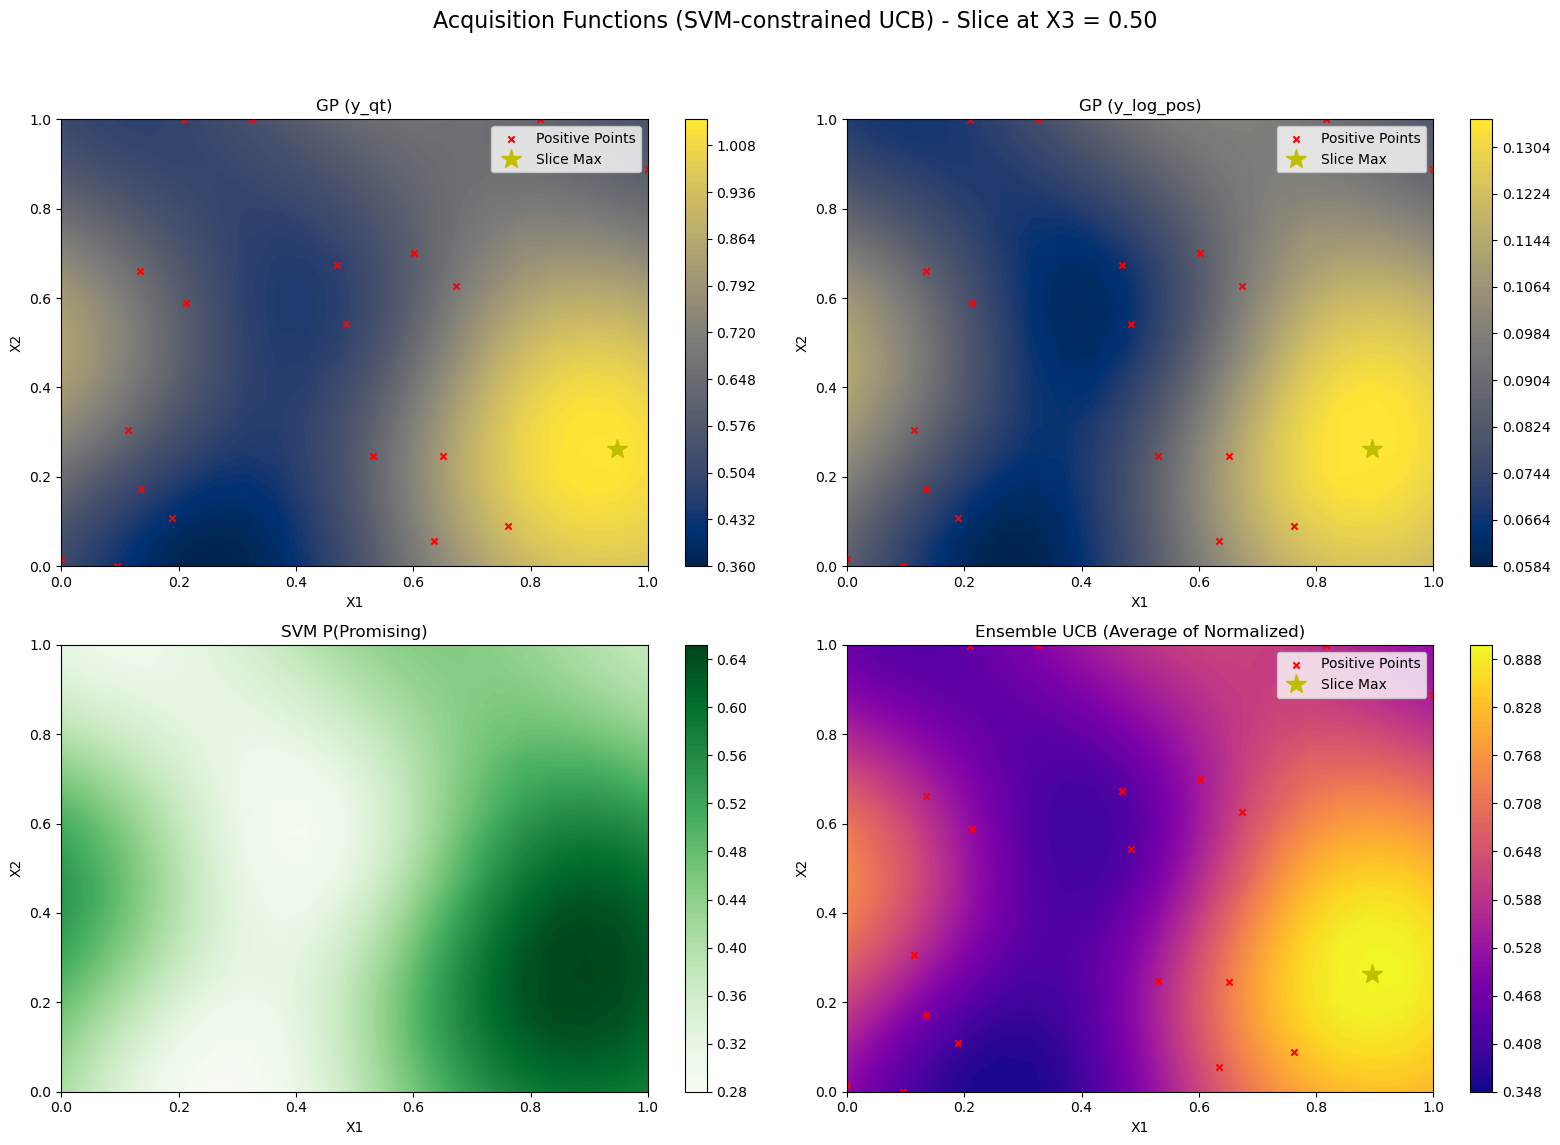

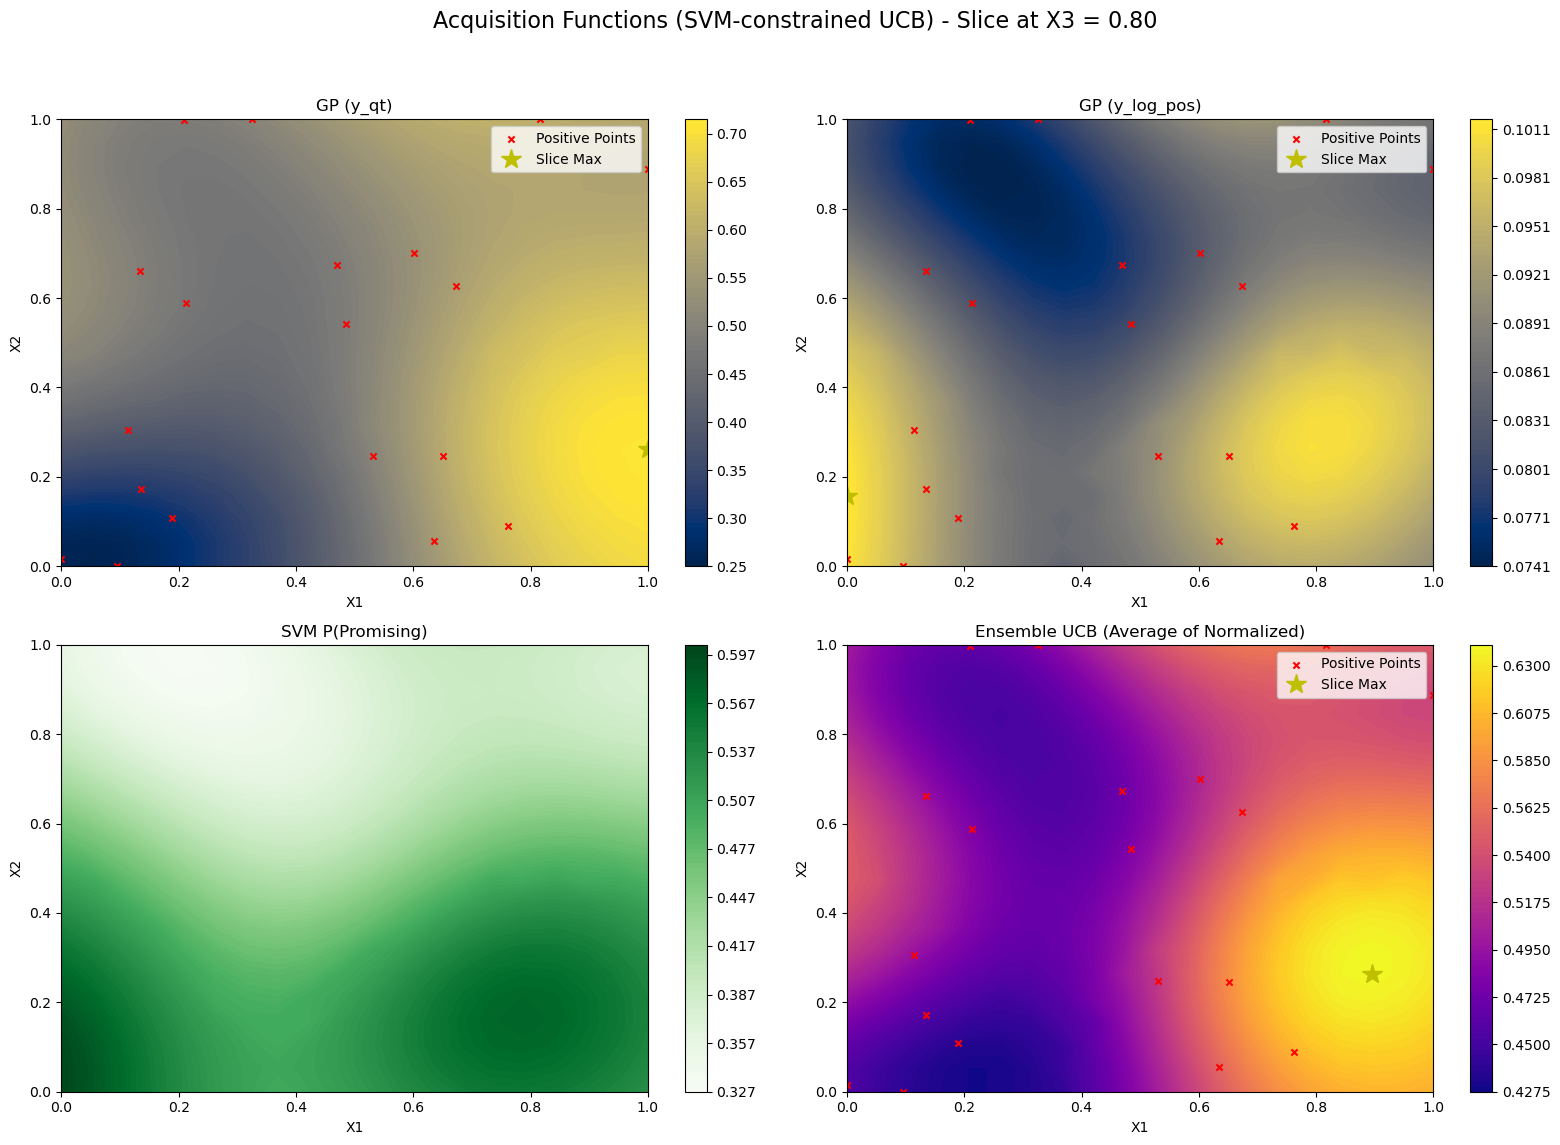

RECOMMENDED NEXT POINT (Ensemble of 2 GPs, 10K LHS candidates)
  Input (original space): [0.848043 0.465799 0.395813]
  SVM P(promising):       0.714

Individual surrogate suggestions:
    GP (y_qt)           : [0.884792 0.502719 0.414794], SVM P=0.698)
    GP (y_log_pos)      : [0.836936 0.339631 0.655023], SVM P=0.586)

Sanity check - is this a corner?
  x1 = 0.8717 
  x2 = 0.3408 
  x3 = 0.3565 

Current best: [0.478263 0.705786 0.066089] (y = -0.032568212033085034)

  SVM grid coverage: 44.8% promising (fail-safe threshold: 5%)
  SVM effective weights: SVM P(promising)


In [6]:

def upper_confidence_bound(mu, sigma, kappa=2.0):
    return mu + kappa * sigma

def constrained_ucb(ucb_vals, svm_proba):
    ucb_shifted = ucb_vals - ucb_vals.min() + 1e-6
    return ucb_shifted * svm_proba

def normalize_01(arr):
    return (arr - arr.min()) / (arr.max() - arr.min() + 1e-10)

# --- Use LHS candidates instead of coarse grid to avoid boundary bias ---
sampler = LatinHypercube(d=3, seed=42)
X_candidates = sampler.random(n=10_000)

# Budget-aware kappa: linear decay from 5.0 (week 1) to 2.0 (week 13)
WEEK = 5
kappa = 5.0 - ((WEEK - 1) / 13) * 3.0
print(f"kappa = {kappa:.4f} (week {WEEK}/13)")

# GP predictions on LHS candidates
mu_gp_qt, sigma_gp_qt = gp_qt.predict(X_candidates, return_std=True)
mu_gp_log, sigma_gp_log = gp_log.predict(X_candidates, return_std=True)

# SVM probability (constraint)
svm_proba = svm_clf.predict_proba(X_candidates)[:, 1]

# Fix A: SVM fail-safe — if SVM collapses to classify <5% of candidates as promising,
# fall back to uniform weights so the constraint doesn't silence the acquisition surface.
if (svm_proba > 0.5).mean() < 0.05:
    print("WARNING: SVM classified <5% of candidates as promising — applying fail-safe (uniform weights).")
    svm_proba_effective = np.ones_like(svm_proba)
else:
    svm_proba_effective = svm_proba

# UCB scores
ucb_gp_qt = upper_confidence_bound(mu_gp_qt, sigma_gp_qt, kappa=kappa)
ucb_gp_log = upper_confidence_bound(mu_gp_log, sigma_gp_log, kappa=kappa)

# SVM-constrained UCB
ucb_c_gp_qt = constrained_ucb(ucb_gp_qt, svm_proba_effective)
ucb_c_gp_log = constrained_ucb(ucb_gp_log, svm_proba_effective)

# Ensemble: average the 2 normalized constrained GP UCBs
ensemble_ucb = (normalize_01(ucb_c_gp_qt) + normalize_01(ucb_c_gp_log)) / 2.0

best_ensemble_idx = np.argmax(ensemble_ucb)
x_next_norm = X_candidates[best_ensemble_idx]
x_next_orig = scaler_X.inverse_transform([x_next_norm])[0]

# Find best point per surrogate for reporting
surrogates = {
    'GP (y_qt)': ucb_c_gp_qt,
    'GP (y_log_pos)': ucb_c_gp_log,
}
best_points = {}
for name, ucb_vals in surrogates.items():
    idx = np.argmax(ucb_vals)
    best_points[name] = {
        'idx': idx,
        'norm': X_candidates[idx],
        'orig': scaler_X.inverse_transform([X_candidates[idx]])[0],
        'svm_p': svm_proba[idx],
    }

# --- Plotting Slices (using grid for visualization) ---
# Recompute on grid for visualization only
svm_proba_grid = svm_clf.predict_proba(X_grid)[:, 1]
mu_qt_grid, sigma_qt_grid = gp_qt.predict(X_grid, return_std=True)
mu_log_grid, sigma_log_grid = gp_log.predict(X_grid, return_std=True)
ucb_qt_grid = constrained_ucb(upper_confidence_bound(mu_qt_grid, sigma_qt_grid, kappa), svm_proba_grid)
ucb_log_grid = constrained_ucb(upper_confidence_bound(mu_log_grid, sigma_log_grid, kappa), svm_proba_grid)
ensemble_grid = (normalize_01(ucb_qt_grid) + normalize_01(ucb_log_grid)) / 2.0

surrogates_grid = {
    'GP (y_qt)': ucb_qt_grid,
    'GP (y_log_pos)': ucb_log_grid,
}

def plot_acquisition_slices(x3_slice):
    _slice_idx = int(x3_slice * (n_grid - 1))
    
    surrogate_slices = {name: val.reshape(n_grid, n_grid, n_grid)[:, :, _slice_idx] for name, val in surrogates_grid.items()}
    svm_proba_slice = svm_proba_grid.reshape(n_grid, n_grid, n_grid)[:, :, _slice_idx]
    ensemble_ucb_slice = ensemble_grid.reshape(n_grid, n_grid, n_grid)[:, :, _slice_idx]
    
    X_train_neg = np.empty((0, X_train.shape[1]))

    plot_acquisition_comparison_slice(
        X1_test[:,:,0], X2_test[:,:,0],
        surrogate_slices, svm_proba_slice, ensemble_ucb_slice,
        X_train_pos, X_train_neg,
        x3_slice_val=x3_slice
    )

for x3_val in [0.2, 0.5, 0.8]:
    plot_acquisition_slices(x3_val)

# --- Summary ---
print(f"{'='*80}")
print(f"RECOMMENDED NEXT POINT (Ensemble of 2 GPs, 10K LHS candidates)")
print(f"{'='*80}")
print(f"  Input (original space): {np.array_str(x_next_orig, precision=6)}")
print(f"  SVM P(promising):       {svm_proba[best_ensemble_idx]:.3f}")

print(f"\nIndividual surrogate suggestions:")
for name, bp in best_points.items():
    print(f"    {name:20s}: {np.array_str(bp['orig'], precision=6)}, SVM P={bp['svm_p']:.3f})")

print(f"\nSanity check - is this a corner?")
for i in range(3):
    at_boundary = x_next_norm[i] < 0.02 or x_next_norm[i] > 0.98
    print(f"  x{i+1} = {x_next_norm[i]:.4f} {'<-- BOUNDARY!' if at_boundary else ''}")

print(f"\nCurrent best: {X_train_raw[np.argmax(y_train_raw)]} (y = {y_train_raw.max()})")
print(f"\n  SVM grid coverage: {(svm_proba > 0.5).mean()*100:.1f}% promising (fail-safe threshold: 5%)")
print(f"  SVM effective weights: {'uniform (fail-safe)' if (svm_proba > 0.5).mean() < 0.05 else 'SVM P(promising)'}")
